In [1]:
import os
chkpt_root = 'checkpoints/fa1t_38_run_2'                                                                                                                      
data_files = 'data/tfrecords/test/*'
tces_file  = 'data/tces-v14-test.csv'

nruns = 10

def load_ensemble(chkpt_root, nruns):
    checkpts = []
    for i in range(nruns):
        parent = os.path.join(chkpt_root, str(i + 1))
        if not os.path.exists(parent):
            break
        all_dirs = os.listdir(parent)
        if not all_dirs:
            break
        d, = all_dirs
        checkpts.append(os.path.join(parent, d))
    return checkpts

paths = load_ensemble(chkpt_root, nruns)
paths

['checkpoints/fa1t_38_run_2\\1\\AstroCNNModel_final_alpha_1_tuned_20260420_141526',
 'checkpoints/fa1t_38_run_2\\2\\AstroCNNModel_final_alpha_1_tuned_20260420_142412',
 'checkpoints/fa1t_38_run_2\\3\\AstroCNNModel_final_alpha_1_tuned_20260420_143249',
 'checkpoints/fa1t_38_run_2\\4\\AstroCNNModel_final_alpha_1_tuned_20260420_144117',
 'checkpoints/fa1t_38_run_2\\5\\AstroCNNModel_final_alpha_1_tuned_20260420_144958',
 'checkpoints/fa1t_38_run_2\\6\\AstroCNNModel_final_alpha_1_tuned_20260420_145836',
 'checkpoints/fa1t_38_run_2\\7\\AstroCNNModel_final_alpha_1_tuned_20260420_150716',
 'checkpoints/fa1t_38_run_2\\8\\AstroCNNModel_final_alpha_1_tuned_20260420_151546',
 'checkpoints/fa1t_38_run_2\\9\\AstroCNNModel_final_alpha_1_tuned_20260420_152421',
 'checkpoints/fa1t_38_run_2\\10\\AstroCNNModel_final_alpha_1_tuned_20260420_153324']

In [ ]:
import getpass
import os
from astronet import predict
import tensorflow as tf


def run_predictions(path):
    predict.FLAGS = predict.parser.parse_args([
      '--model_dir', path,
      '--data_files', data_files,
      '--output_file', '',
    ])

    return predict.predict()


paths = load_ensemble(chkpt_root, nruns)
ensemble_preds = []
config = None
for i, path in enumerate(paths):
    print(f'Running model {i + 1}')
    preds, config = run_predictions(path)
    ensemble_preds.append(preds.set_index('astro_id'))
    print()

In [37]:
labels = ['disp_e', 'disp_n', 'disp_j', 'disp_s', 'disp_b']

col_e = labels.index('disp_e')
thresh = 0.215

In [38]:
import numpy as np
import pandas as pd

agg_preds = {}

for preds in ensemble_preds:
    for ex_id in preds.index:
        if ex_id not in agg_preds:
            agg_preds[ex_id] = []

        row = preds[preds.index == ex_id]
        pred_v = row.values[0]
        if len(row.values) > 1:
            print(f'Warning: duplicate predictions for {ex_id}')
        if pred_v[col_e] >= thresh:
            agg_preds[ex_id].append('disp_e')
        else:
            masked_v = [v if i != col_e else 0 for i, v in enumerate(pred_v)]
            agg_preds[ex_id].append(preds.columns[np.argmax(masked_v)])

In [39]:
final_preds = []
for ex_id in list(agg_preds.keys()):
    counts = {l: 0 for l in labels}
    for e in agg_preds[ex_id]:
        counts[e] += 1
    maxcount = max(counts.values())
    counts.update({
        'astro_id': ex_id,
        'maxcount': maxcount,
    })
    final_preds.append(counts)
    
final_preds = pd.DataFrame(final_preds).set_index('astro_id')

In [40]:
tce_table = pd.read_csv(tces_file, header=0, low_memory=False)
tce_table['astro_id'] = tce_table['Astro ID']
tce_table = tce_table.set_index('astro_id')
for l in labels:
    tce_table[l] = tce_table[l[:-1] + l[-1].upper()]
tce_labels = tce_table[labels + ['TIC ID']]

pl = final_preds.join(tce_labels, on='astro_id', how='left', lsuffix='_p')

pl.head()
pd.set_option('display.max_columns', None)

In [41]:
ppos = (pl['disp_e_p'] > 0)
pos = (pl['disp_e'] > 0)

pneg = (pl['disp_e_p'] == 0)
neg = (pl['disp_e'] == 0)

print('Recall:', len(pl[ppos & pos]) / len(pl[pos]))
print('Precision:', len(pl[ppos & pos]) / len(pl[ppos]))

Recall: 0.964
Precision: 0.7461300309597523


In [42]:
for i in pl[pos & pneg]['TIC ID']:
    print(i)

31265416.0
419736605.0
384074629.0
69549569.0
116252237.0
117789567.0
129012152.0
105020452.0
142352523.0


In [43]:
for i in pl[neg & ppos]['TIC ID']:
    print(i)

404850274.0
456564311.0
466657734.0
21683845.0
277108565.0
112988537.0
404933760.0
365608020.0
340206201.0
358273925.0
294923253.0
337350767.0
31694643.0
29984231.0
419736622.0
426032062.0
387067244.0
382254048.0
90717083.0
404559668.0
355363175.0
310420324.0
373779556.0
290304391.0
270367355.0
380394964.0
350146296.0
404006437.0
149498072.0
295372879.0
409747080.0
231744905.0
183306212.0
229810745.0
372203477.0
279161482.0
129333155.0
28168394.0
403625251.0
116575240.0
198883710.0
91329106.0
354129146.0
99867387.0
135171750.0
14739172.0
256326226.0
372711165.0
317347811.0
275122166.0
136756300.0
238652338.0
41680093.0
445605526.0
2041549164.0
40457215.0
418013928.0
282650563.0
256003229.0
468716176.0
240403806.0
395084760.0
313421138.0
164410859.0
29171191.0
28177695.0
136466789.0
157880926.0
459221499.0
50354055.0
408093233.0
392909786.0
64905065.0
298895276.0
260281851.0
123982605.0
129115637.0
155989608.0
17059855.0
277535606.0
369643357.0
38586438.0


In [44]:
def compare(ensemble_preds, filter):
    result = ensemble_preds[0][filter]
    for preds in ensemble_preds[1:]:
        result = result.append(preds[filter])
    return result

# compare(ensemble_preds, preds.index == pl[pl['TIC ID'] == 28484801].index.values[0])

In [27]:
# pl[pl.index == pl[pl['TIC ID'] == 1254504863].index.values[0]]

### PR curve

In [45]:
ids = set(ensemble_preds[0].index.values)

index = {v: i for i, v in enumerate(ids)}

pred_es = np.zeros([len(ensemble_preds), len(index)])
for i, preds in enumerate(ensemble_preds):
    for row in preds.iterrows():
        ex_id, pred_e = row[0], row[1].iloc[col_e]
        pred_es[i][index[ex_id]] = pred_e

lbl_es = np.zeros([len(index)], dtype=bool)
for row in tce_labels.iterrows():
    ex_id, lbl_e = row[0], row[1]['disp_e']
    lbl_es[index[ex_id]] = (lbl_e > 0)

In [46]:
num_cond_pos = int(np.sum(lbl_es))

def pr_at_th(th):
    pred_pos = np.mean(pred_es, axis=0) >= th
    true_pos = pred_pos & lbl_es
    num_pred_pos = int(np.sum(pred_pos))
    num_true_pos = int(np.sum(true_pos))
    if num_pred_pos == 0:
        return 1.0, 0.0
    return float(num_true_pos) / float(num_pred_pos), float(num_true_pos) / float(num_cond_pos)

AUC: 0.9656682558838079, max R: 1.0, max P: 1.0
100% recall at: 46%, threshold: 0.00800000000005463


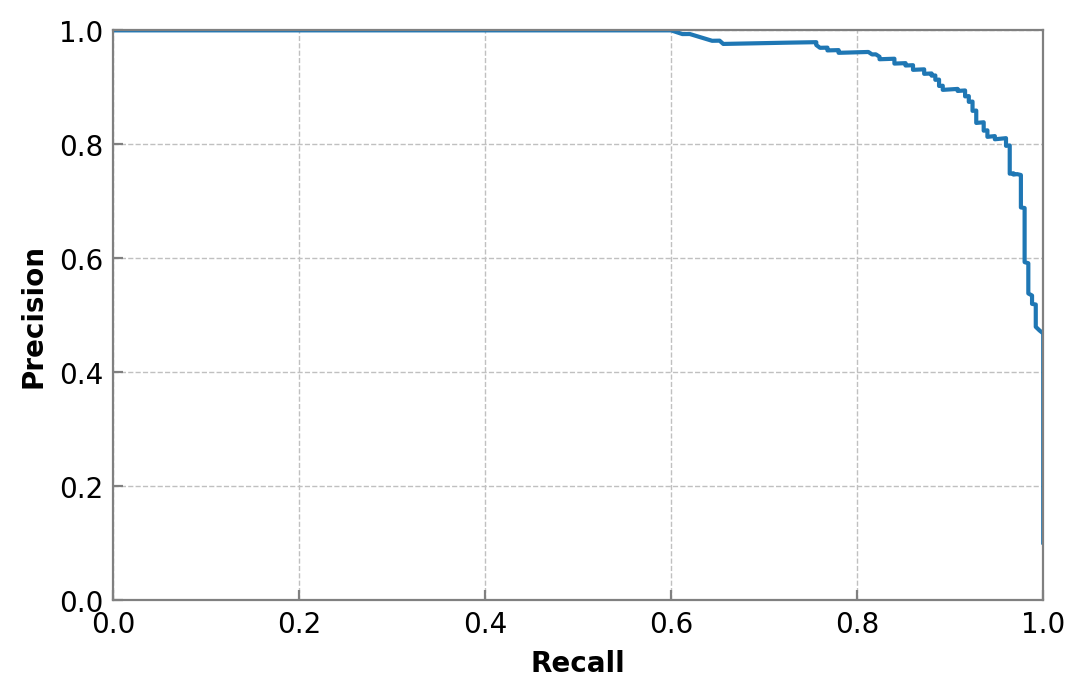

In [47]:
from matplotlib import pyplot as plt

ps, rs, ths = ([], [], [])
th = np.max(pred_es)
while th >= 0.0:
    p, r = pr_at_th(th)
    ps.append(p)
    rs.append(r)
    ths.append(th)
    th -= 0.0005
    
from sklearn import metrics

print(f'AUC: {metrics.auc(rs, ps)}, max R: {max(rs)}, max P: {max(ps)}')
    
i = len(rs) - 1
while rs[i] == 1.0:
    i -= 1
i += 1
print(f'100% recall at: {int(ps[i] * 100)}%, threshold: {ths[i]}')

fig, ax = plt.subplots(figsize=(6, 3.7), dpi=200)

ax.spines['top'].set_color('#808080')
ax.spines['right'].set_color('#808080')
ax.spines['left'].set_color('#808080')
ax.spines['bottom'].set_color('#808080')
ax.tick_params(direction='in', color='#808080')

plt.grid(color='#c0c0c0', linestyle='--', linewidth=0.5)

plt.ylabel('Precision', fontweight='bold')
plt.xlabel('Recall', fontweight='bold')

plt.xlim((0.0, 1.0))
plt.ylim((0.0, 1.0))

_ = plt.plot(rs, ps)

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

pred_cols = [l + '_p' for l in labels]
true_cols = labels

y_pred = np.array(labels)[pl[pred_cols].values.argmax(axis=1)]
y_true = np.array(labels)[pl[true_cols].values.argmax(axis=1)]

cm = confusion_matrix(y_true, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=[f'true {l}' for l in labels], columns=[f'pred {l}' for l in labels])
print(cm_df)

fig, ax = plt.subplots(figsize=(6, 5), dpi=150)
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticklabels(labels)
ax.set_xlabel('Predicted', fontweight='bold')
ax.set_ylabel('True', fontweight='bold')
ax.set_title('Confusion matrix (ensemble majority vote)')

thresh_color = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > thresh_color else 'black')

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


                 pred not disp_E  pred disp_E
true not disp_E             2184           82
true disp_E                    9          241
TP=241  FP=82  FN=9  TN=2184
Precision: 0.7461   Recall: 0.9640


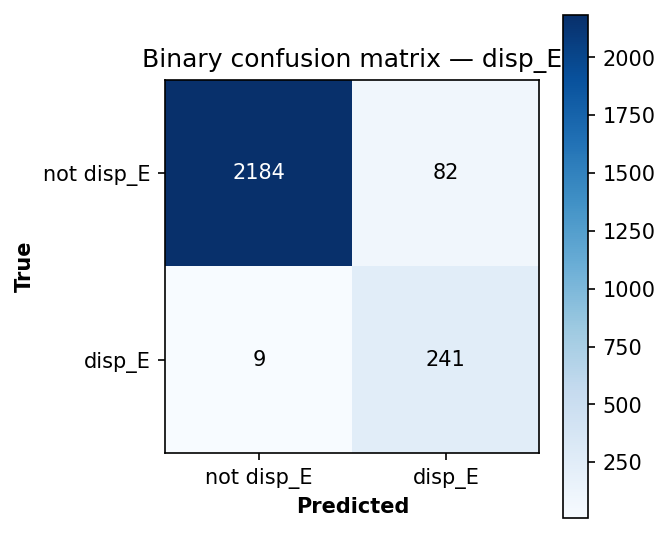

In [49]:
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

bin_labels = ['not disp_E', 'disp_E']
y_pred_bin = (pl['disp_e_p'] > 0).astype(int)
y_true_bin = (pl['disp_e'] > 0).astype(int)

cm = confusion_matrix(y_true_bin, y_pred_bin, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
cm_df = pd.DataFrame(cm, index=[f'true {l}' for l in bin_labels], columns=[f'pred {l}' for l in bin_labels])
print(cm_df)
print(f'TP={tp}  FP={fp}  FN={fn}  TN={tn}')
print(f'Precision: {tp / (tp + fp):.4f}   Recall: {tp / (tp + fn):.4f}')

fig, ax = plt.subplots(figsize=(4.5, 4), dpi=150)
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(bin_labels); ax.set_yticklabels(bin_labels)
ax.set_xlabel('Predicted', fontweight='bold')
ax.set_ylabel('True', fontweight='bold')
ax.set_title('Binary confusion matrix — disp_E')

thresh_color = cm.max() / 2.0
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > thresh_color else 'black')

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()
